In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [24]:
#Setting
TRANSFORMED_PATH = "drug_consumption_transformed.csv"
NUMERIC_PATH = "drug_consumption_numeric.csv"
CLASS_ORDER = ["CL0", "CL1", "CL2", "CL3", "CL4", "CL5", "CL6"]
CLASS_TO_CODE = {c: i for i, c in enumerate(CLASS_ORDER)}
CODE_TO_CLASS = {i: c for i, c in enumerate(CLASS_ORDER)}
N_SPLITS = 3
C_GRID = np.array([0.01, 0.1, 1, 10, 100])

In [25]:
#Functions
def TC(C: np.ndarray) -> float:
    N = C.sum()
    M = len(C)
    ns = C.sum(axis=0)
    cost = 0.0
    for i in range(M):
        for j in range(M):
            if ns[i] == 0:
                continue
            gamma = (N - ns[j]) / ns[i]
            cost += C[i, j] * gamma * abs(i - j)
    return float(cost)

def encode_response(y_raw: pd.Series) -> np.ndarray:
    y = y_raw.astype(str).map(CLASS_TO_CODE)
    if y.isna().any():
        bad = y_raw[y.isna()].unique()
        raise ValueError(f"Unknown response values found: {bad}")
    return y.astype(int).to_numpy()

def load_transformed_data(path: str):
    df = pd.read_csv(path)
    y = encode_response(df["choc"])
    X = df.drop(columns=["choc"]).copy()
    X = pd.get_dummies(X, drop_first=True)
    X = X.astype(float)
    return X.reset_index(drop=True), y

def load_numeric_data(path: str):
    df = pd.read_csv(path)
    y = encode_response(df["choc"])
    X = df.drop(columns=["choc"]).copy()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    if len(cat_cols) > 0:
        print("Numeric data columns being one-hot encoded:", cat_cols)
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X = X.astype(float)
    return X.reset_index(drop=True), y

def confusion_from_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    m = len(CLASS_ORDER)
    C = np.zeros((m, m), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        C[yp, yt] += 1
    return C

def accuracy_from_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(y_true == y_pred))

def save_confusion_matrix(C: np.ndarray, filename: str):
    C_df = pd.DataFrame(C, index=CLASS_ORDER, columns=CLASS_ORDER)
    C_df.to_csv(filename)
    return C_df

def scale_train_test(X_train: pd.DataFrame, X_test: pd.DataFrame):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

In [26]:
#K-fold
def kfold_ordered_logit(X: pd.DataFrame, y: np.ndarray, label: str, n_splits=3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=432)
    pred = np.zeros(len(y), dtype=int)
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        model = OrderedModel(
            endog=y_train,
            exog=X_train,
            distr="logit"
        )
        result = model.fit(method="bfgs", maxiter=1000, disp=False)
        prob = result.predict(X_test)
        pred[test_idx] = np.argmax(np.asarray(prob), axis=1)
        print(f"{label}: fold {fold}/{n_splits} complete")
    return pred

def kfold_multinomial_logistic(X: pd.DataFrame, y: np.ndarray, C_value: float, label: str, n_splits=3):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=432)
    pred = np.zeros(len(y), dtype=int)
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        X_train_scaled, X_test_scaled = scale_train_test(X_train, X_test)
        clf = LogisticRegression(
            C=C_value,
            penalty="l2",
            solver="lbfgs",
            max_iter=5000
        )
        clf.fit(X_train_scaled, y_train)
        pred[test_idx] = clf.predict(X_test_scaled)
        print(f"{label}, C={C_value}: fold {fold}/{n_splits} complete")
    return pred

In [27]:
#Eva
def evaluate_predictions(y_true: np.ndarray, y_pred: np.ndarray, prefix: str):
    C = confusion_from_predictions(y_true, y_pred)
    acc = accuracy_from_predictions(y_true, y_pred)
    tc = TC(C)
    print(f"\n{prefix}")
    print("Accuracy:", acc)
    print("TC:", tc)
    C_df = pd.DataFrame(C, index=CLASS_ORDER, columns=CLASS_ORDER)
    print(C_df)
    save_confusion_matrix(C, f"{prefix}_confusion_matrix.csv")
    return {
        "confusion_matrix": C,
        "accuracy": acc,
        "tc": tc
    }


def evaluate_multinomial_grid(y_true: np.ndarray, pred_mat: np.ndarray, c_grid: np.ndarray, prefix: str):
    rows = []
    best_idx = None
    best_tc = np.inf
    best_acc = None
    best_C = None
    best_Cmat = None
    for j, C_value in enumerate(c_grid):
        y_pred = pred_mat[j, :]
        Cmat = confusion_from_predictions(y_true, y_pred)
        acc = accuracy_from_predictions(y_true, y_pred)
        tc = TC(Cmat)
        rows.append({
            "C": C_value,
            "accuracy": acc,
            "tc": tc
        })
        if tc < best_tc:
            best_tc = tc
            best_idx = j
            best_acc = acc
            best_C = C_value
            best_Cmat = Cmat.copy()
    tuning_df = pd.DataFrame(rows)
    tuning_df.to_csv(f"{prefix}_tuning.csv", index=False)
    save_confusion_matrix(best_Cmat, f"{prefix}_best_confusion_matrix.csv")
    print(f"\n{prefix}")
    print("Best C:", best_C)
    print("Best Accuracy:", best_acc)
    print("Best TC:", best_tc)
    print(pd.DataFrame(best_Cmat, index=CLASS_ORDER, columns=CLASS_ORDER))
    return {
        "best_idx": best_idx,
        "best_C": best_C,
        "best_accuracy": best_acc,
        "best_tc": best_tc,
        "best_confusion_matrix": best_Cmat,
        "tuning_df": tuning_df
    }

In [28]:
#Plot
def plot_tuning_curve(tuning_df: pd.DataFrame, title: str, filename: str):
    best_row = tuning_df.loc[tuning_df["tc"].idxmin()]
    plt.figure(figsize=(7, 5))
    plt.plot(np.log10(tuning_df["C"]), tuning_df["tc"], marker="o")
    plt.scatter(np.log10(best_row["C"]), best_row["tc"], s=80)
    plt.xlabel("log10(C)")
    plt.ylabel("Total Misclassification Cost")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

def fit_full_ordered_logit_for_plot(X: pd.DataFrame, y: np.ndarray):
    model = OrderedModel(
        endog=y,
        exog=X,
        distr="logit"
    )
    result = model.fit(method="bfgs", maxiter=1000, disp=False)
    return result

def plot_ordered_logit_coefficients(result, filename="Model Coef.png"):
    params = result.params.copy()
    conf_int = result.conf_int().copy()
    conf_int.columns = ["ci_lower", "ci_upper"]
    coef_df = pd.concat([params, conf_int], axis=1)
    coef_df.columns = ["coef", "ci_lower", "ci_upper"]
    coef_df = coef_df.loc[~coef_df.index.str.contains(r"/", regex=True)].copy()
    keep_vars = [
        "nscore", "escore", "oscore", "ascore", "cscore",
        "age_25-34", "age_35-44", "age_45-54", "age_55-64", "age_65+",
        "gender_Male",
        "education_University degree", "education_Masters degree"
    ]
    keep_vars = [v for v in keep_vars if v in coef_df.index]
    coef_df = coef_df.loc[coef_df.index.isin(keep_vars)].copy()
    label_map = {
        "nscore": "Neuroticism",
        "escore": "Extraversion",
        "oscore": "Openness",
        "ascore": "Agreeableness",
        "cscore": "Conscientiousness",
        "age_25-34": "Age 25--34",
        "age_35-44": "Age 35--44",
        "age_45-54": "Age 45--54",
        "age_55-64": "Age 55--64",
        "age_65+": "Age 65+",
        "gender_Male": "Male",
        "education_University degree": "University Degree",
        "education_Masters degree": "Master's Degree"
    }
    coef_df["label"] = coef_df.index.map(label_map)
    coef_df = coef_df.sort_values("coef")
    y_pos = np.arange(len(coef_df))
    plt.figure(figsize=(8, 6))
    plt.errorbar(
        x=coef_df["coef"],
        y=y_pos,
        xerr=[
            coef_df["coef"] - coef_df["ci_lower"],
            coef_df["ci_upper"] - coef_df["coef"]
        ],
        fmt="o",
        capsize=4
    )
    plt.axvline(x=0, linestyle="--")
    plt.yticks(y_pos, coef_df["label"])
    plt.xlabel("Estimated Coefficient")
    plt.ylabel("")
    plt.title("Selected Coefficients from the 7-Class Ordered Logit Model")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

Loading transformed data...
Loading numeric data...
Numeric data columns being one-hot encoded: ['gender', 'country', 'ethnicity']

Shapes:
Categorical: (1885, 28)
Numeric: (1885, 20)

Response distribution:
0     32
1      3
2     10
3     54
4    296
5    683
6    807
Name: count, dtype: int64
Ordered Logit categorical: fold 1/3 complete


C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


Ordered Logit categorical: fold 2/3 complete
Ordered Logit categorical: fold 3/3 complete

ordered_logit_cat
Accuracy: 0.413262599469496
TC: 2929.0014555600196
     CL0  CL1  CL2  CL3  CL4  CL5  CL6
CL0    0    0    0    0    0    0    0
CL1    0    0    0    0    0    0    0
CL2    0    0    0    0    0    0    0
CL3    0    0    0    0    0    0    0
CL4    0    0    0    0    2    5    2
CL5   16    3    3   23  144  222  250
CL6   16    0    7   31  150  456  555
Ordered Logit numeric: fold 1/3 complete
Ordered Logit numeric: fold 2/3 complete
Ordered Logit numeric: fold 3/3 complete

ordered_logit_num
Accuracy: 0.42917771883289124
TC: 2881.2093215369437
     CL0  CL1  CL2  CL3  CL4  CL5  CL6
CL0    0    0    0    0    0    0    0
CL1    0    0    0    0    0    0    0
CL2    0    0    0    0    0    0    0
CL3    0    0    0    0    0    0    0
CL4    0    0    0    0    1    4    0
CL5   17    3    3   21  139  227  226
CL6   15    0    7   33  156  452  581
Multinomial categoric

C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\wkh26

Multinomial categorical, C=1.0: fold 2/3 complete
Multinomial categorical, C=1.0: fold 3/3 complete
Multinomial categorical, C=10.0: fold 1/3 complete
Multinomial categorical, C=10.0: fold 2/3 complete


...

C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\wkh26

Multinomial numeric, C=1.0: fold 3/3 complete
Multinomial numeric, C=10.0: fold 1/3 complete
Multinomial numeric, C=10.0: fold 2/3 complete
Multinomial numeric, C=10.0: fold 3/3 complete


C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\wkh26

Multinomial numeric, C=100.0: fold 1/3 complete
Multinomial numeric, C=100.0: fold 2/3 complete
Multinomial numeric, C=100.0: fold 3/3 complete

multinomial_logit_num
Best C: 0.01
Best Accuracy: 0.43183023872679044
Best TC: 2980.9443362267766
     CL0  CL1  CL2  CL3  CL4  CL5  CL6
CL0    0    0    0    0    0    0    0
CL1    0    0    0    0    0    0    0
CL2    0    0    0    0    0    0    0
CL3    0    0    0    0    0    0    0
CL4    0    0    0    1    3    8    3
CL5    9    1    3   14   90  154  147
CL6   23    2    7   39  203  521  657


C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\wkh26\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


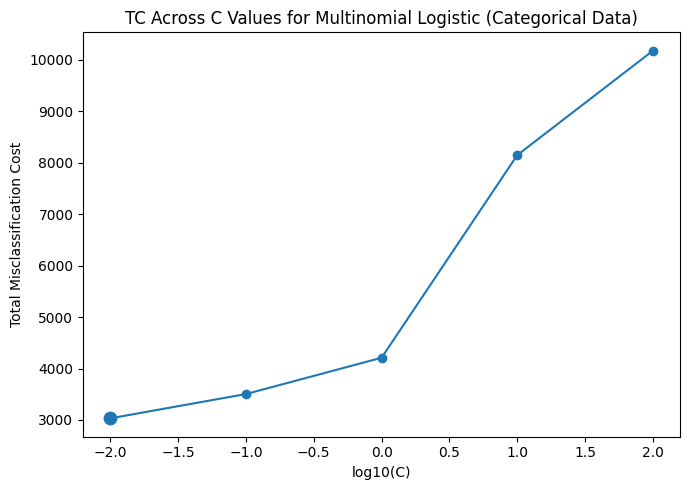

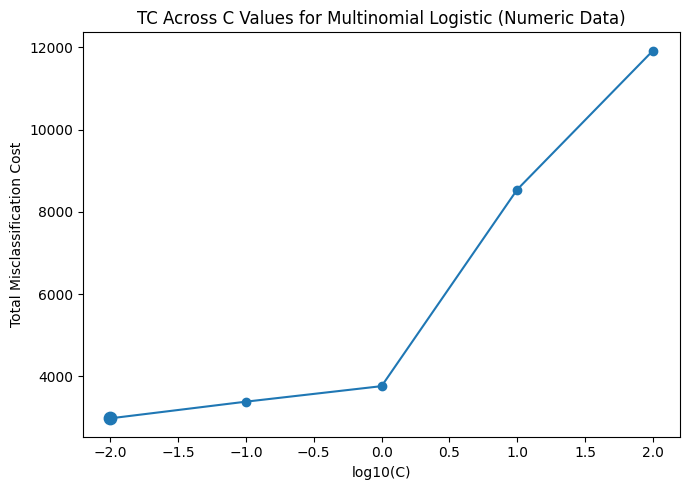

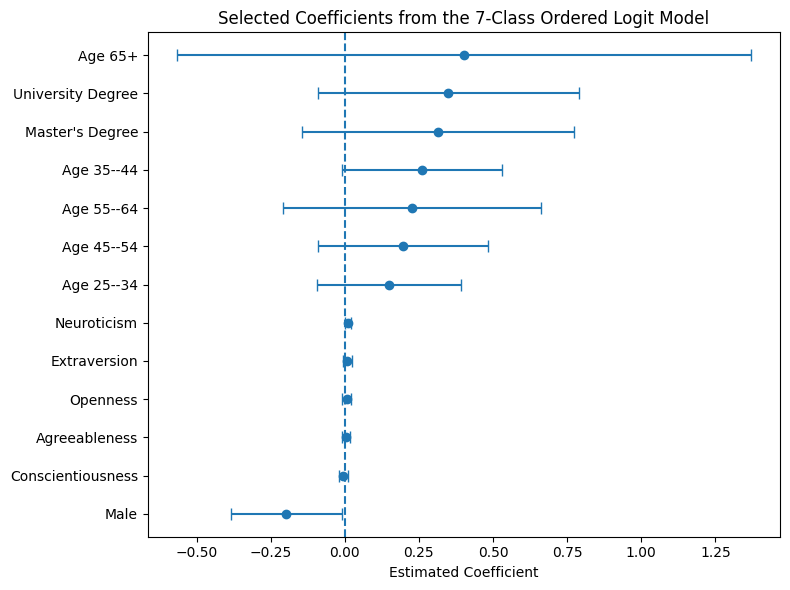


Final summary:
                  model data_version best_parameter  accuracy           tc
1         Ordered Logit      Numeric            N/A  0.429178  2881.209322
0         Ordered Logit  Categorical            N/A  0.413263  2929.001456
3  Multinomial Logistic      Numeric           0.01  0.431830  2980.944336
2  Multinomial Logistic  Categorical           0.01  0.413793  3031.427414


In [29]:
#Main
def main():
    print("Loading transformed data...")
    X_cat, y_cat = load_transformed_data(TRANSFORMED_PATH)
    print("Loading numeric data...")
    X_num, y_num = load_numeric_data(NUMERIC_PATH)
    if not np.array_equal(y_cat, y_num):
        raise ValueError("The response vectors differ between transformed and numeric datasets.")
    y = y_cat.copy()
    print("\nShapes:")
    print("Categorical:", X_cat.shape)
    print("Numeric:", X_num.shape)
    print("\nResponse distribution:")
    print(pd.Series(y).value_counts().sort_index())
    pred_ord_cat = kfold_ordered_logit(X_cat, y, "Ordered Logit categorical", n_splits=N_SPLITS)
    pd.DataFrame({"true": y, "pred": pred_ord_cat}).to_csv("ordered_logit_pred_cat.csv", index=False)
    ord_cat_res = evaluate_predictions(y, pred_ord_cat, "ordered_logit_cat")
    pred_ord_num = kfold_ordered_logit(X_num, y, "Ordered Logit numeric", n_splits=N_SPLITS)
    pd.DataFrame({"true": y, "pred": pred_ord_num}).to_csv("ordered_logit_pred_num.csv", index=False)
    ord_num_res = evaluate_predictions(y, pred_ord_num, "ordered_logit_num")
    pred_multi_cat = np.zeros((len(C_GRID), len(y)), dtype=int)
    for j, C_value in enumerate(C_GRID):
        pred_multi_cat[j, :] = kfold_multinomial_logistic(
            X_cat, y, C_value, "Multinomial categorical", n_splits=N_SPLITS
        )
    pd.DataFrame(pred_multi_cat).to_csv("multinomial_logit_pred_cat.csv", index=False)
    pd.DataFrame({"C": C_GRID}).to_csv("multinomial_logit_C_grid.csv", index=False)
    multi_cat_res = evaluate_multinomial_grid(
        y, pred_multi_cat, C_GRID, "multinomial_logit_cat"
    )
    pred_multi_num = np.zeros((len(C_GRID), len(y)), dtype=int)
    for j, C_value in enumerate(C_GRID):
        pred_multi_num[j, :] = kfold_multinomial_logistic(
            X_num, y, C_value, "Multinomial numeric", n_splits=N_SPLITS
        )
    pd.DataFrame(pred_multi_num).to_csv("multinomial_logit_pred_num.csv", index=False)
    multi_num_res = evaluate_multinomial_grid(
        y, pred_multi_num, C_GRID, "multinomial_logit_num"
    )
    plot_tuning_curve(
        multi_cat_res["tuning_df"],
        "TC Across C Values for Multinomial Logistic (Categorical Data)",
        "multinomial_logit_cat_tuning.png"
    )
    plot_tuning_curve(
        multi_num_res["tuning_df"],
        "TC Across C Values for Multinomial Logistic (Numeric Data)",
        "multinomial_logit_num_tuning.png"
    )
    ord_full = fit_full_ordered_logit_for_plot(X_cat, y)
    coef_table = pd.DataFrame({
        "Coefficient": ord_full.params,
        "Odds_Ratio": np.exp(ord_full.params)
    })
    coef_table.to_csv("ordered_logit_full_data_coefficients.csv")
    plot_ordered_logit_coefficients(ord_full, filename="Model Coef.png")
    summary_df = pd.DataFrame([
        {
            "model": "Ordered Logit",
            "data_version": "Categorical",
            "best_parameter": "N/A",
            "accuracy": ord_cat_res["accuracy"],
            "tc": ord_cat_res["tc"]
        },
        {
            "model": "Ordered Logit",
            "data_version": "Numeric",
            "best_parameter": "N/A",
            "accuracy": ord_num_res["accuracy"],
            "tc": ord_num_res["tc"]
        },
        {
            "model": "Multinomial Logistic",
            "data_version": "Categorical",
            "best_parameter": multi_cat_res["best_C"],
            "accuracy": multi_cat_res["best_accuracy"],
            "tc": multi_cat_res["best_tc"]
        },
        {
            "model": "Multinomial Logistic",
            "data_version": "Numeric",
            "best_parameter": multi_num_res["best_C"],
            "accuracy": multi_num_res["best_accuracy"],
            "tc": multi_num_res["best_tc"]
        }
    ])

    summary_df = summary_df.sort_values("tc")
    summary_df.to_csv("logistic_regression_summary.csv", index=False)
    print("\nFinal summary:")
    print(summary_df)

if __name__ == "__main__":
    main()